# 인공 신경망

<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/rickiepark/hg-mldl2/blob/main/07-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>

In [30]:
# 실행마다 동일한 결과를 얻기 위해 케라스에 랜덤 시드를 사용하고 텐서플로 연산을 결정적으로 만듭니다.
import keras 
import tensorflow as tf 

keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

## 패션 MNIST

In [31]:
import keras 

(train_input, train_target), (test_input, test_target) = \
    keras.datasets.fashion_mnist.load_data()

In [32]:
print(train_input.shape, train_target.shape)

(60000, 28, 28) (60000,)


In [33]:
print(test_input.shape, test_target.shape)

(10000, 28, 28) (10000,)


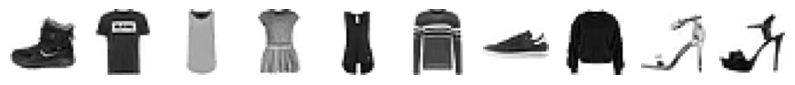

In [34]:
import matplotlib.pyplot as plt 

fig, axs = plt.subplots(1, 10, figsize=(10, 10))
for i in range(10):
    axs[i].imshow(train_input[i], cmap='gray_r')
    axs[i].axis('off')
plt.show()

In [35]:
print(train_target[:10])

[9 0 0 3 0 2 7 2 5 5]


In [36]:
import numpy as np 

print(np.unique(train_target, return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))


## 로지스틱 회귀로 패션 아이템 분류하기

In [40]:
train_scaled = train_input / 255.0
train_scaled = train_scaled.reshape(-1, 28 * 28)

In [38]:
print(train_scaled.shape)

(60000, 784)


In [39]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(loss='log_loss', max_iter=5, random_state=42)
scores = cross_validate(sc, train_scaled, train_target, n_jobs=-1)
print(np.mean(scores['test_score']))

/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_stochastic

0.8194166666666666


## 인공신경망

### 텐서플로와 케라스

In [41]:
import tensorflow as tf

In [42]:
import keras 

In [43]:
keras.config.backend()

'tensorflow'

In [44]:
import os 
os.environ["KERAS_BACKEND"] = "torch"  # 또는 "jax"

## 인공신경망으로 모델 만들기

In [45]:
from sklearn.model_selection import train_test_split 

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

In [47]:
print(train_scaled.shape, train_target.shape)

(48000, 784) (48000,)


In [48]:
print(val_scaled.shape, val_target.shape)

(12000, 784) (12000,)


In [49]:
inputs = keras.layers.Input(shape=(784,))

In [50]:
dense = keras.layers.Dense(10, activation='softmax')

In [52]:
model = keras.Sequential([inputs, dense])

## 인공신경망으로 패션 아이템 분류하기

In [53]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [54]:
print(train_target[:10])

[7 3 5 8 6 9 3 3 9 9]


In [55]:
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7947 - loss: 0.6069
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8388 - loss: 0.4742
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8470 - loss: 0.4501
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8512 - loss: 0.4374
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8544 - loss: 0.4291


In [56]:
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8458 - loss: 0.4444


[0.4444444477558136, 0.8458333611488342]